In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.stats import mannwhitneyu
import scipy.stats as stats
import scipy.stats as kruskal
import scikit_posthocs as sp
import statsmodels.api as sm
from visualizer import DataVisualizer

# 1. Load Data

Loanding 'cleaned_rent_data' to dataframe and create a copy.

In [2]:
df_raw = pd.read_csv('cleaned_rent_data.csv')
df = df_raw.copy()

In [3]:
df.head()

,id,date,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,...,collegeDistance,pharmacyDistance,ownership,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,price_per_m2
0,2a1a6db97ff122d6bc148abb6f0e498a,2023-11-01,szczecin,blockOfFlats,52.0,2.0,3,3,2008.0,53.460535,...,2.200,0.307,condominium,1,1,0,0,0,3500,67.31
1,5a0cb42c088eadf75aa98a4118640048,2023-11-01,szczecin,blockOfFlats,57.0,3.0,5,10,1976.0,53.440955,...,1.323,0.189,condominium,0,1,1,0,0,3000,52.63
2,996722490efcb4b34d48bb84a9a72838,2023-11-01,szczecin,blockOfFlats,43.4,2.0,3,4,1995.0,53.435746,...,0.714,0.211,condominium,0,1,0,0,0,1900,43.78
3,50d75c688530b9a61ba505301e0b94a9,2023-11-01,szczecin,apartmentBuilding,32.6,2.0,5,6,2021.0,53.421582,...,0.689,0.192,condominium,0,1,1,0,0,2500,76.69
4,9b187f4203adabf466fd08610d8f4e5e,2023-11-01,szczecin,apartmentBuilding,72.0,3.0,6,6,2014.0,53.450010,...,1.387,0.315,condominium,0,1,1,0,1,2999,41.65


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70054 entries, 0 to 70053
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    70054 non-null  object 
 1   date                  70054 non-null  object 
 2   city                  70054 non-null  object 
 3   type                  70054 non-null  object 
 4   squareMeters          70054 non-null  float64
 5   rooms                 70054 non-null  float64
 6   floor                 70054 non-null  int64  
 7   floorCount            70054 non-null  int64  
 8   buildYear             70054 non-null  float64
 9   latitude              70054 non-null  float64
 10  longitude             70054 non-null  float64
 11  centreDistance        70054 non-null  float64
 12  poiCount              70054 non-null  float64
 13  schoolDistance        70054 non-null  float64
 14  clinicDistance        70054 non-null  float64
 15  postOfficeDistance 

In [5]:
df.shape

(70054, 28)

# 2. Hypothesis Testing: Price Comparison by Building Type

In this part of the analysis, I will test the hypothesis that the median rental  price and median price per square meter are the same for both **blockOfFlats** and **tenements**.

## 2.1 Data Preparation

In [6]:
df_block = df[df['type'] == 'blockOfFlats']
df_tenement = df[df['type'] == 'tenement']

### 2.1.1 Price

In [7]:
block_price = df_block['price']
tenement_price = df_tenement['price']

In [8]:
block_median_price = block_price.median()
tenement_median_price = tenement_price.median()

### 2.1.2 Price per Square Meter

In [9]:
block_price_m2 = df_block['price_per_m2']
tenement_price_m2 = df_tenement['price_per_m2']

In [10]:
block_median_per_m2 = block_price_m2.median()
tenement_median_per_m2 = tenement_price_m2.median()

## 2.2 Data Visualization

### 2.2.1 Data Visualization - Price

In [11]:
viz_block_price = DataVisualizer(df_block)
viz_tenement_price = DataVisualizer(df_tenement)

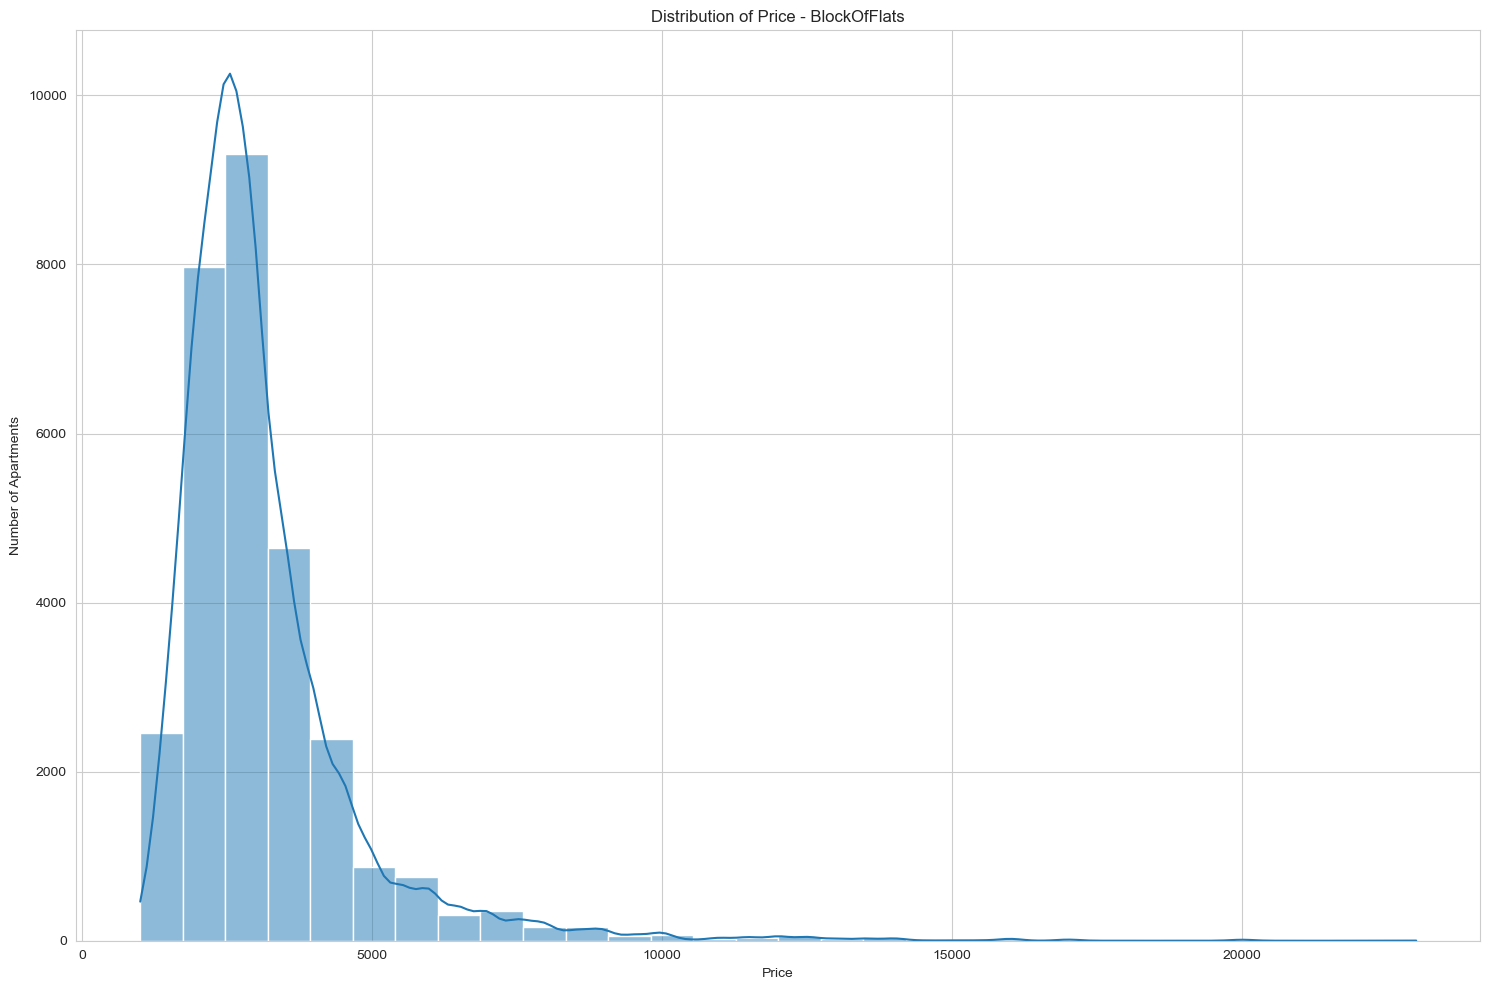

In [12]:
viz_block_price.histplots(['price'],['Distribution of Price - BlockOfFlats'],['Price'],1,1,None)

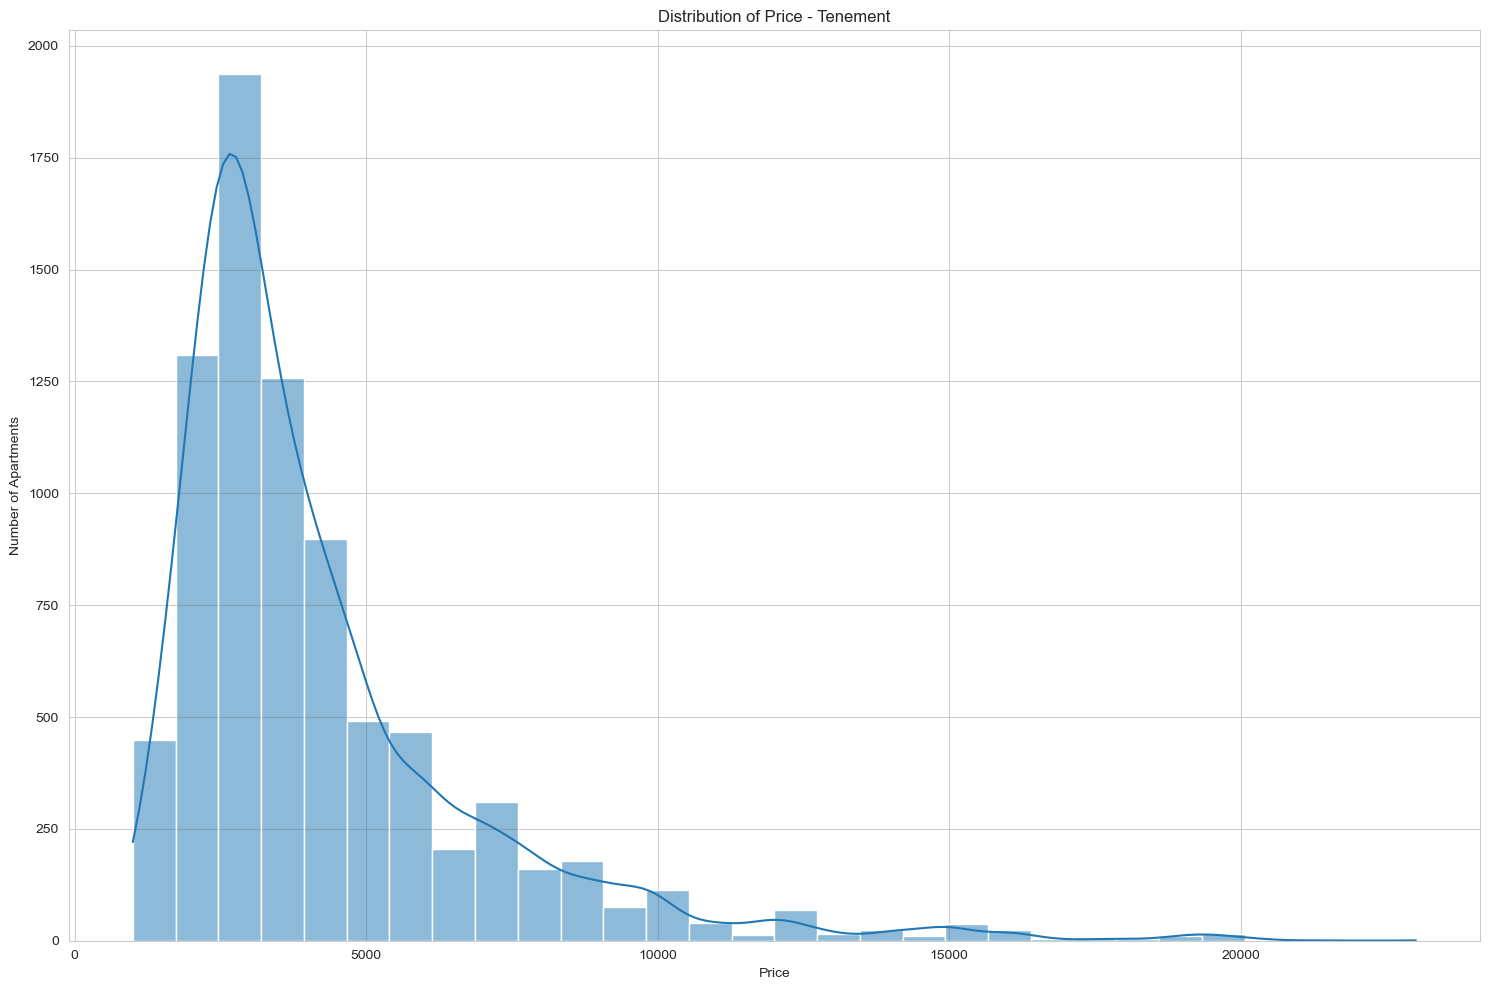

In [13]:
viz_tenement_price.histplots(['price'],['Distribution of Price - Tenement'],['Price'],1,1,None)

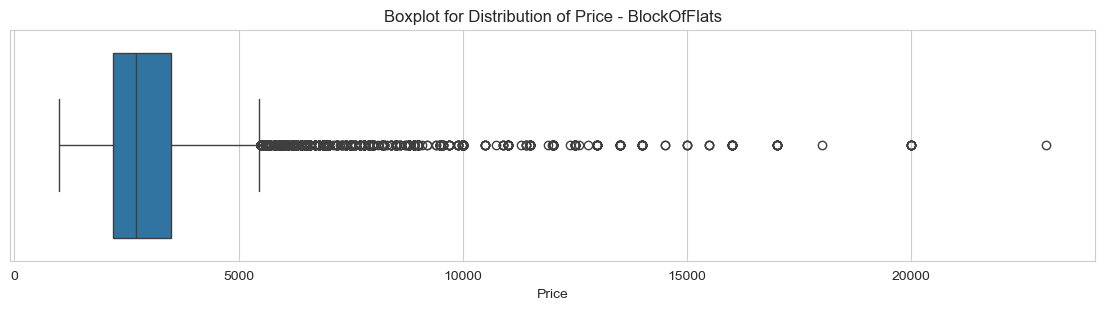

In [14]:
viz_block_price.boxplots(['price'],['Distribution of Price - BlockOfFlats'],['Price'])

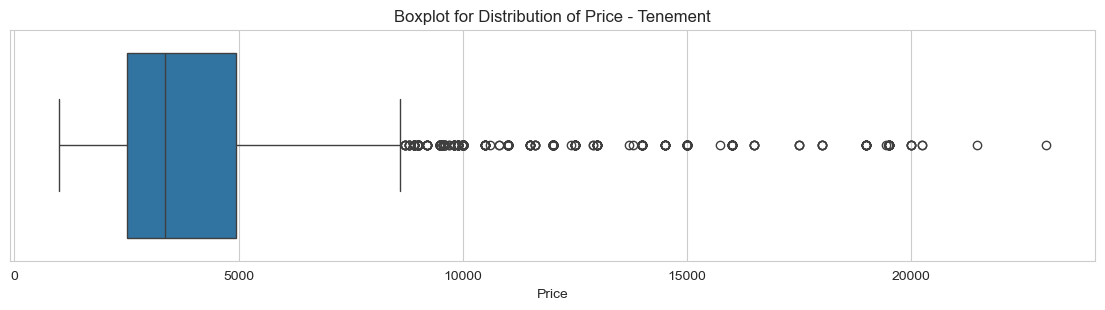

In [15]:
viz_tenement_price.boxplots(['price'],['Distribution of Price - Tenement'],['Price'])

### 2.2.2 Data Visualization - Price Per Square Meter

In [16]:
viz_block_price_m2 = DataVisualizer(df_block)
viz_tenement_price_m2 = DataVisualizer(df_tenement)

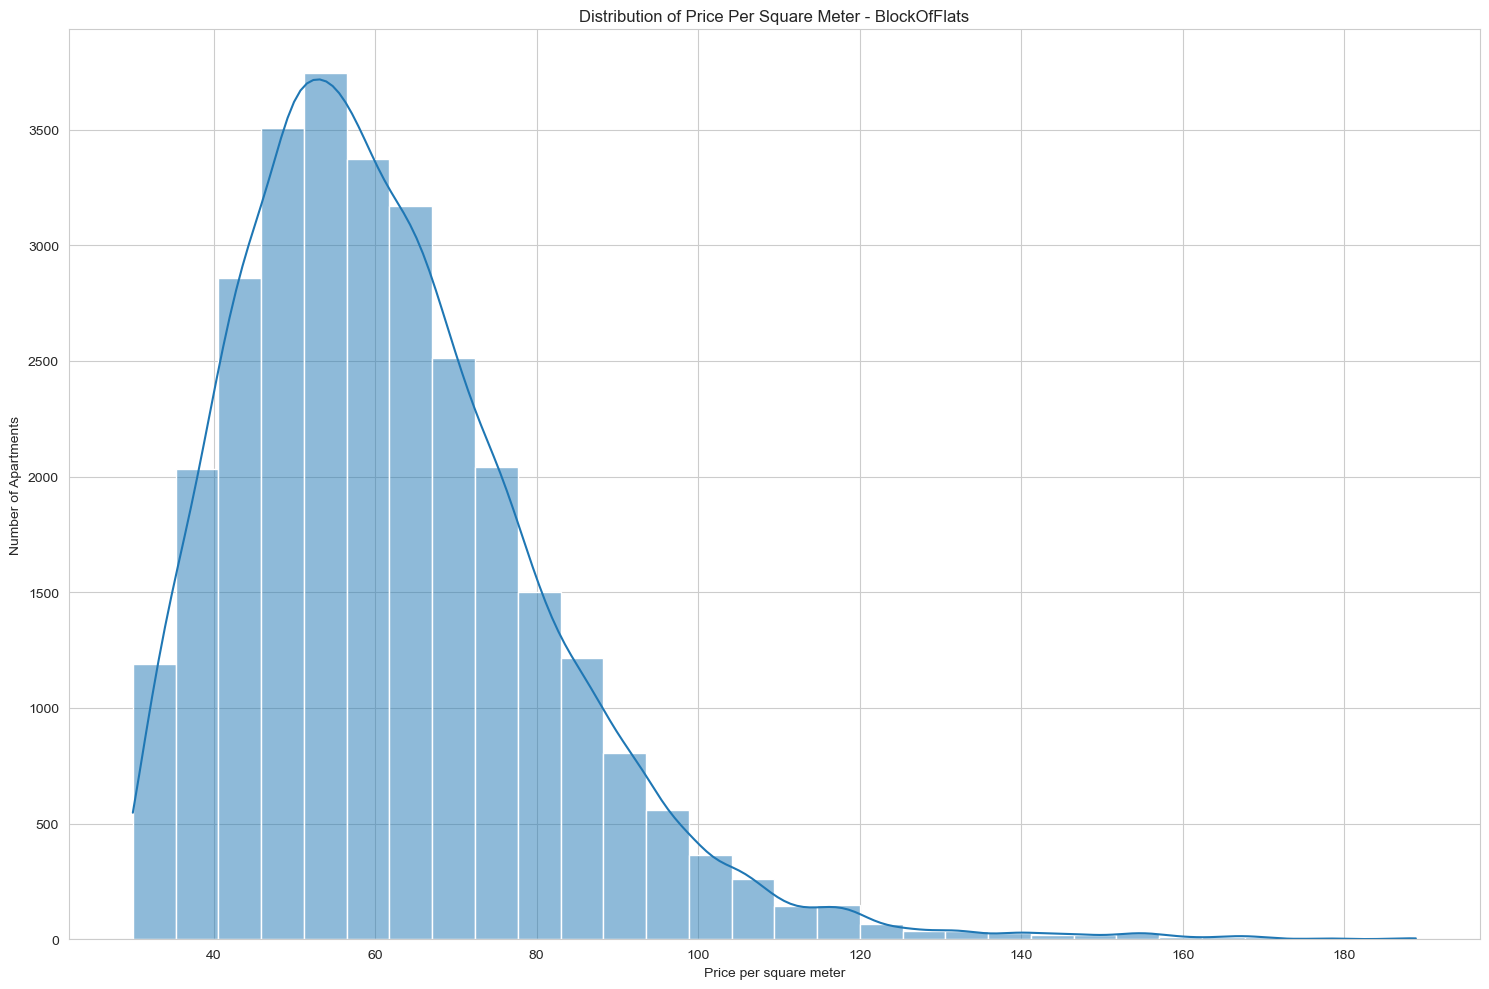

In [17]:
viz_block_price_m2.histplots(['price_per_m2'],['Distribution of Price Per Square Meter - BlockOfFlats'],['Price per square meter'],1,1,None)

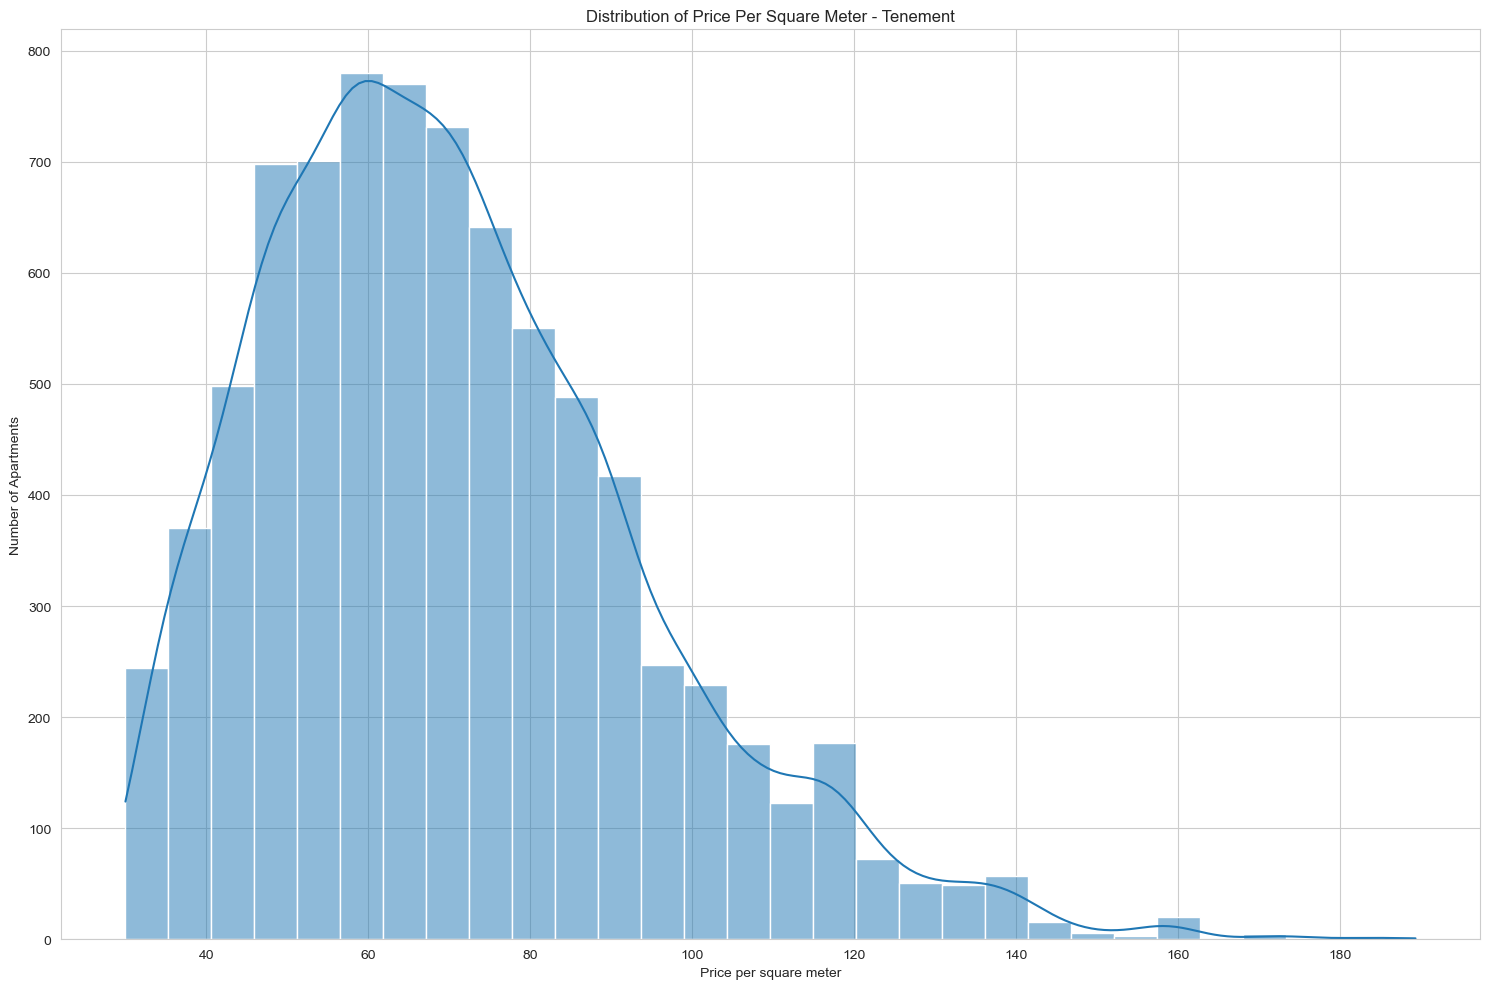

In [18]:
viz_tenement_price_m2.histplots(['price_per_m2'],['Distribution of Price Per Square Meter - Tenement'],['Price per square meter'],1,1,None)

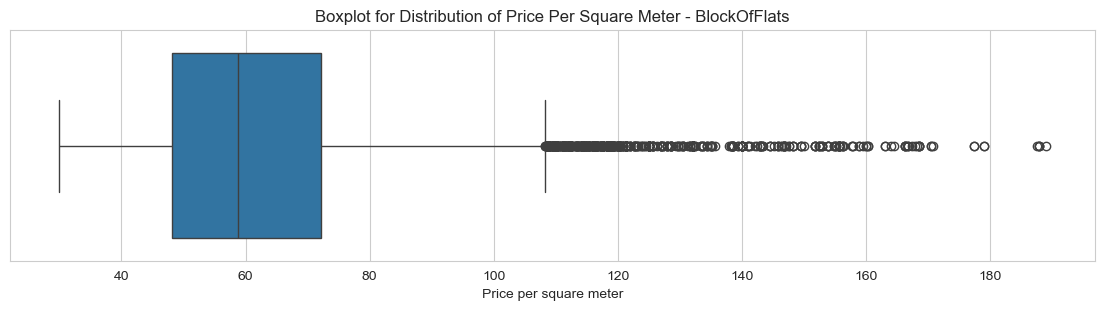

In [19]:
viz_block_price_m2.boxplots(['price_per_m2'],['Distribution of Price Per Square Meter - BlockOfFlats'],['Price per square meter'])

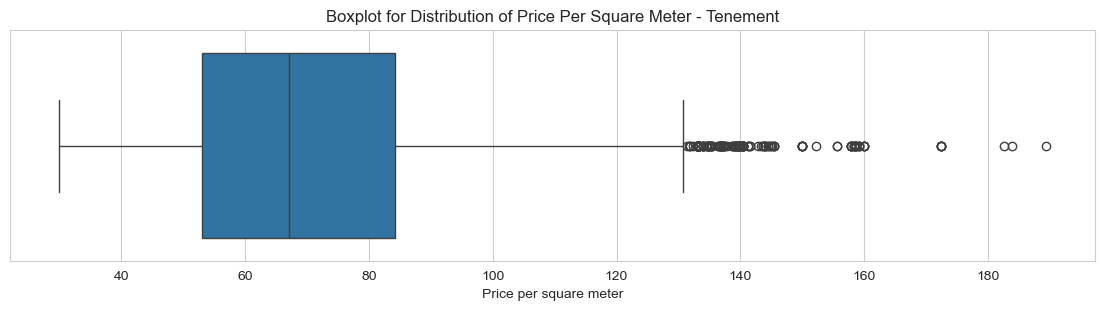

In [20]:
viz_tenement_price_m2.boxplots(['price_per_m2'],['Distribution of Price Per Square Meter - Tenement'],['Price per square meter'])

**Insights:**

Graphical analysis of the total price and price per square meter shows that the distributions are right-skewed in both groups. Due to the fact that the assumption of normal distribution is not met, applying a parametric test (e.g., Student's t-test) could lead to incorrect conclusions. For this reason, I decided to use the non-parametric Mann-Whitney U test.

## 2.3 Mann-Whitney U test - Price

**Hypotheses for the Mann-Whitney U test**

* **H0** The median rental price for block of flats and tenement are equal.
* **H1** The median rental price for block of flats ana tenement are not equal.

In [21]:
stat, pvalue = stats.mannwhitneyu(block_price,tenement_price, alternative='two-sided')

In [22]:
print(f"U-Mann Whitney Statistic: {stat}")
print(f"P value: {pvalue}")
print(f"Median price for Block of Flats: {block_median_price} and Median price for Tenement: {tenement_median_price}")

U-Mann Whitney Statistic: 86990426.0
P value: 0.0
Median price for Block of Flats: 2700.0 and Median price for Tenement: 3365.0


**Insights:**

The resulting p-value (~0.000) is lower than the common significance level of $\alpha = 0.05$. This gives us grounds to reject H0 in favor of the alternative hypothesis. This signifies that the medians for both groups are statistically significantly different (at a 95% confidence level). Looking at the median values (**2700** vs **3365**), it can be stated with certainty that apartments in blockOfFlats are cheaper than those in tenements

## 2.4 Mann-Whitney U test - Price Per Square Meter

**Hypotheses for the Mann-Whitney U test**
* **H0** The median price per square meter for block of flats and tenement are equal
* **H1** The median price per square meter for block of flats and tenement are not equal

In [23]:
stat, pvalue = stats.mannwhitneyu(block_price_m2,tenement_price_m2,alternative='two-sided')

In [24]:
print(f"U-Mann Whitney Statistic: {stat}")
print(f"P value: {pvalue}")
print(f"Median price per square meter for Block Of Flats: {block_median_per_m2}  and Median price per square meter for Tenement: {tenement_median_per_m2}")

U-Mann Whitney Statistic: 93796676.5
P value: 2.2422934750812705e-208
Median price per square meter for Block Of Flats: 58.82  and Median price per square meter for Tenement: 67.175


**Insights:**

The resulting p-value(~0.000) is lower than the common significance level $\alpha = 0.05$. This given us grounds to reject H0 in favor of the alternative hypothesis. This signifies that the medians for both groups are statisticaly different (at a 95% confidence level). Looking at the median values (**58.82** vs **67.18**), it can be stated with certainty that the price per square meter for apartments in **blockOfFlat** is lower tha for those in **tenement**.

# 4. Statistical Market Segmentation: The 3-Tier City Model

## 4.1 Data Preparation

In [25]:
cluster_1_cities = ['krakow','gdynia','gdansk','wroclaw']
cluster_2_cities = ['szczecin','katowice','lublin','poznan','rzeszow']
cluster_3_cities = ['radom','bialystok','czestochowa','bydgoszcz','lodz']
df_cluster_1 = df[df['city'].isin(cluster_1_cities)]
df_cluster_2 = df[df['city'].isin(cluster_2_cities)]
df_cluster_3 = df[df['city'].isin(cluster_3_cities)]

### 4.1.1 Price

In [26]:
cluster_1_median_price = df_cluster_1.groupby('city')['price'].median()
cluster_2_median_price = df_cluster_2.groupby('city')['price'].median()
cluster_3_median_price = df_cluster_3.groupby('city')['price'].median()

### 4.1.2 Price per Square Meter

In [27]:
cluster_1_median_per_m2 = df_cluster_1.groupby('city')['price_per_m2'].median()
cluster_2_median_per_m2 = df_cluster_2.groupby('city')['price_per_m2'].median()
cluster_3_median_per_m2 = df_cluster_3.groupby('city')['price_per_m2'].median()

## 4.2 Data Visualization 

In [28]:
viz_cluster_1 = DataVisualizer(df_cluster_1)
viz_cluster_2 = DataVisualizer(df_cluster_2)
viz_cluster_3 = DataVisualizer(df_cluster_3)

### 4.2.1 Data Visualization - Price

#### 4.2.1.1 Cluster 1 - Price

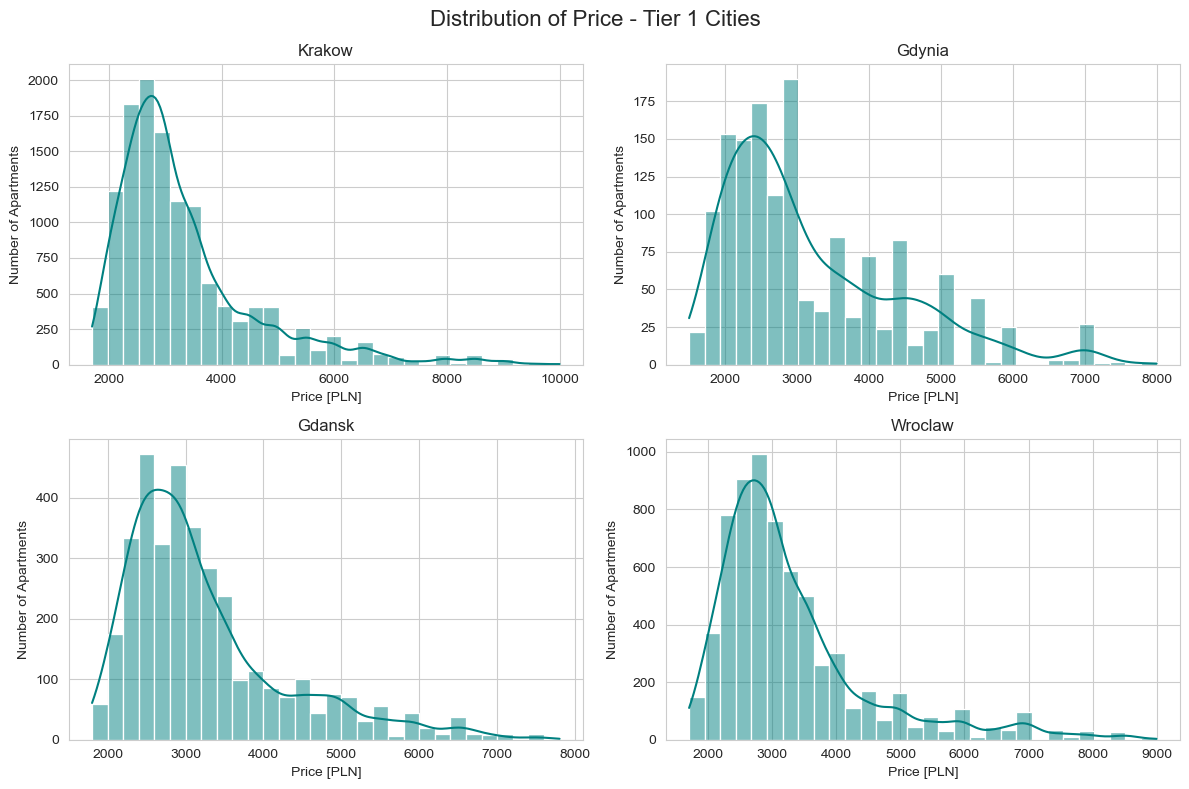

In [29]:
viz_cluster_1.histplots_test(cluster_1_cities,'price','Distribution of Price - Tier 1 Cities',2,2)

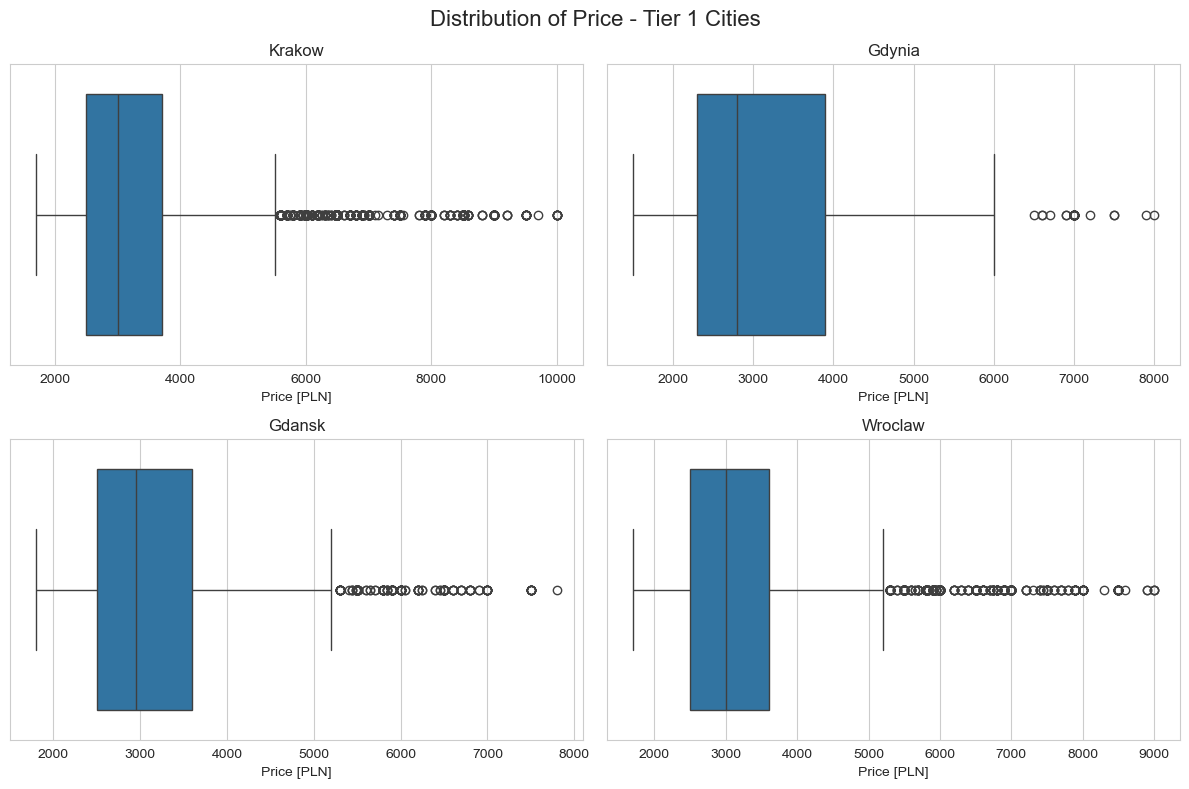

In [30]:
viz_cluster_1.boxplots_test(cluster_1_cities,'price', 'Distribution of Price - Tier 1 Cities',2,2)

#### 4.2.1.2 Cluster 2 - Price

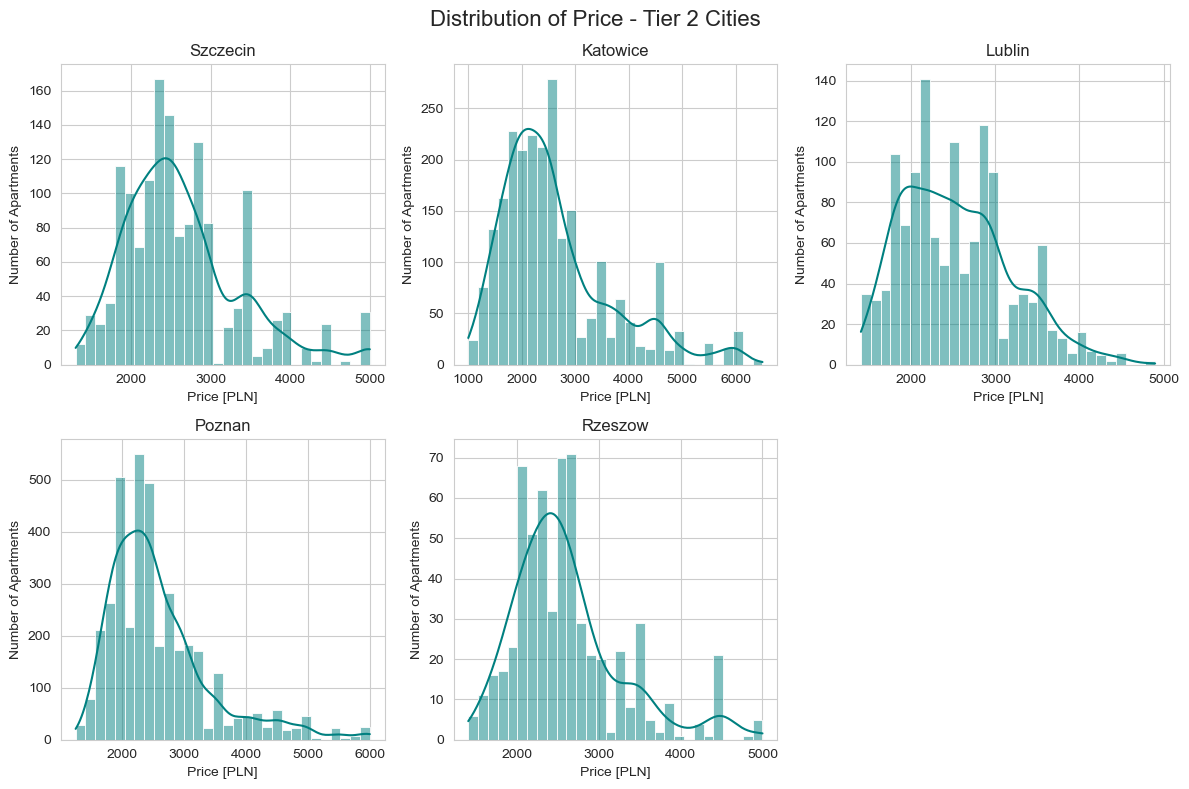

In [31]:
viz_cluster_2.histplots_test(cluster_2_cities,'price',  'Distribution of Price - Tier 2 Cities', 2, 3)

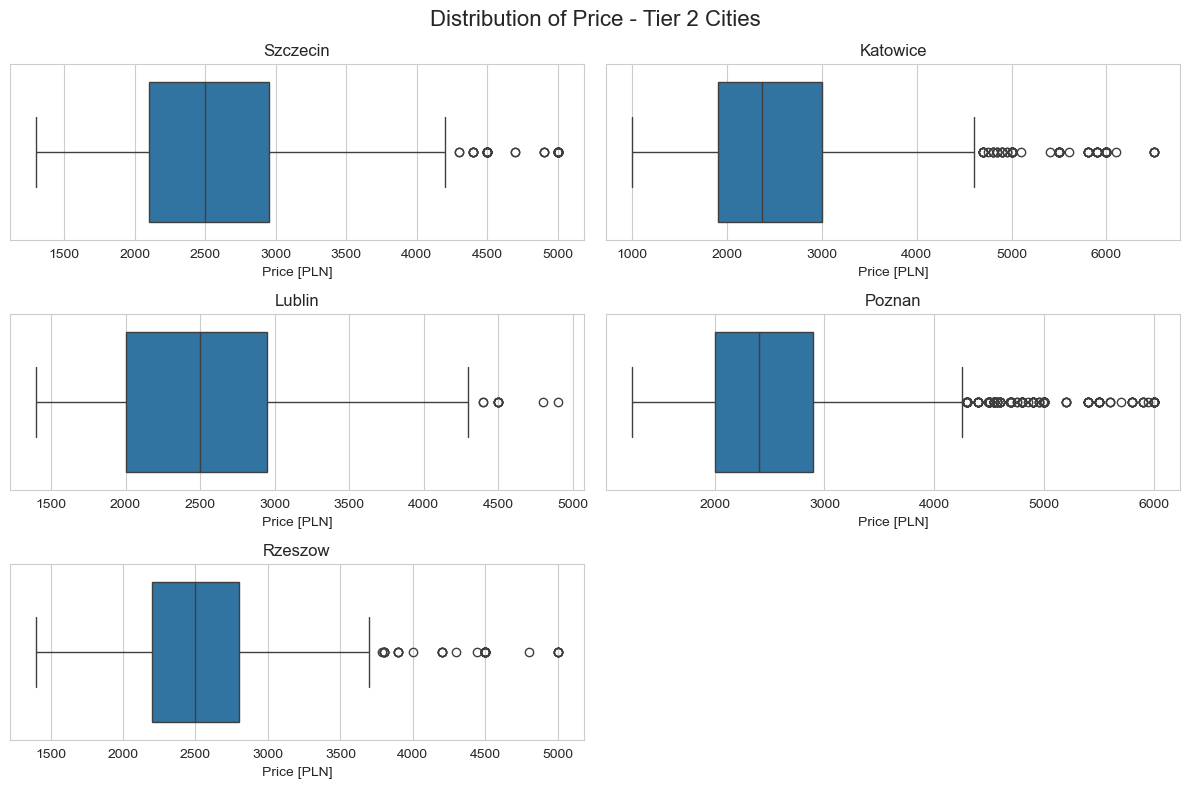

In [32]:
viz_cluster_2.boxplots_test(cluster_2_cities,'price',  'Distribution of Price - Tier 2 Cities', 3,2)

#### 4.2.1.3 Cluster 3 - Price

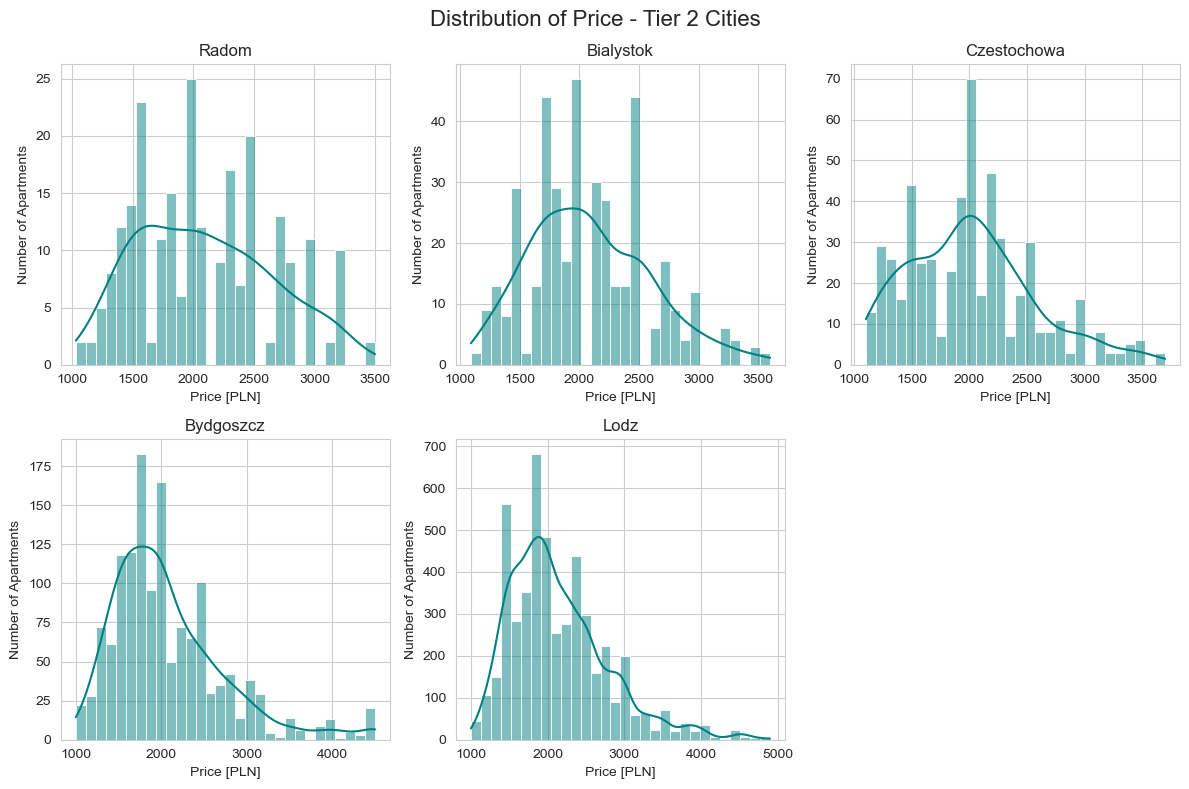

In [33]:
viz_cluster_3.histplots_test(cluster_3_cities,'price',  'Distribution of Price - Tier 2 Cities', 2, 3)

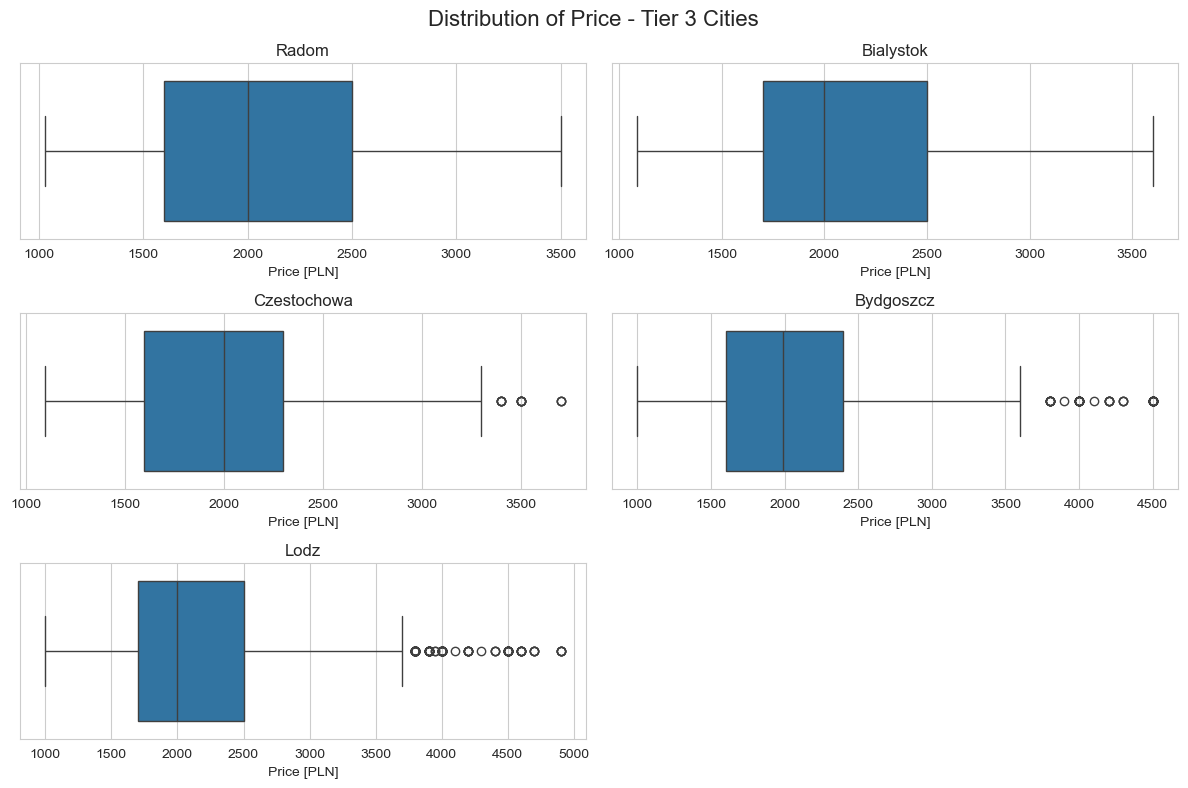

In [34]:
viz_cluster_3.boxplots_test(cluster_3_cities,'price',  'Distribution of Price - Tier 3 Cities', 3,2)

Visual inspection of the histograms and boxplots clearly reveals that the price distributions across the cities are heavily right-skewed and exhibit non-normal characteristics.

**Conclusion:**
Since the fundamental assumption of a normal distribution required for parametric testing is visibly violated, the non-parametric Krukal-Wallis test is the most appropriate.

### 4.2.2 Data Visualization - Price per Square Meter

#### 4.2.2.1 Cluster 1

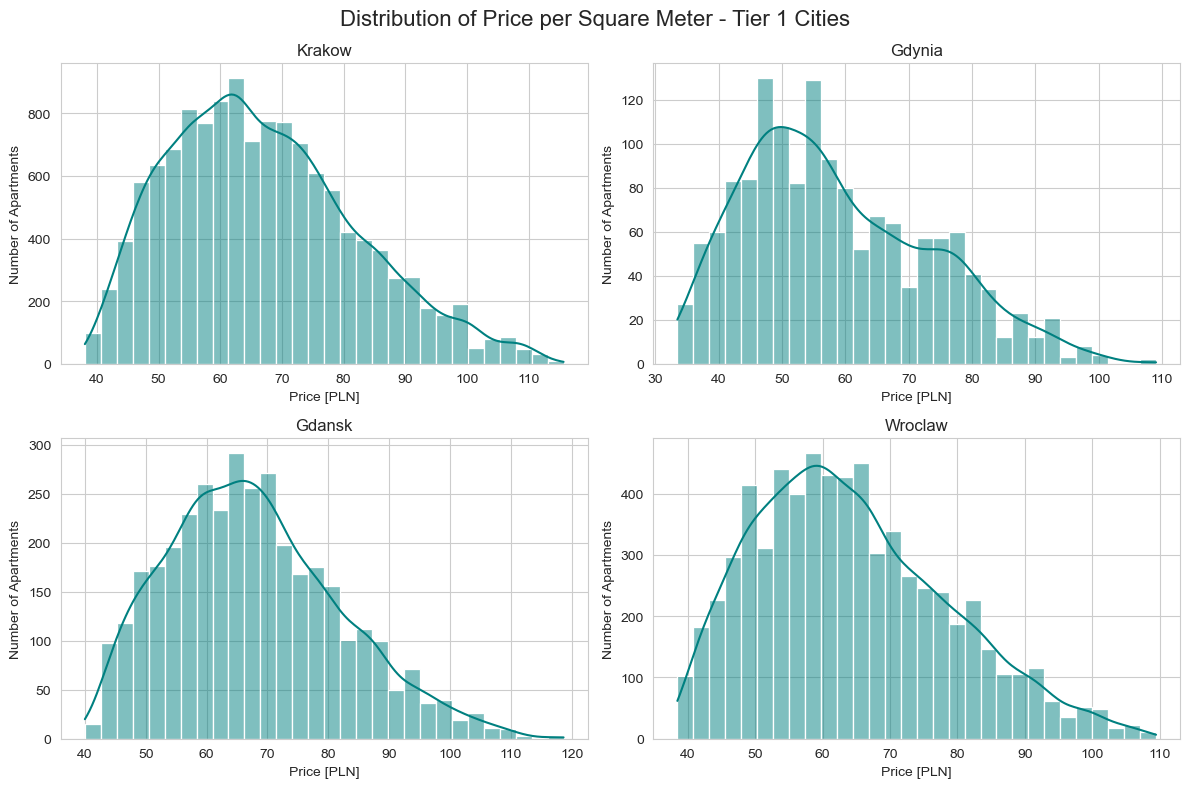

In [35]:
viz_cluster_1.histplots_test(cluster_1_cities,'price_per_m2','Distribution of Price per Square Meter - Tier 1 Cities',2,2)

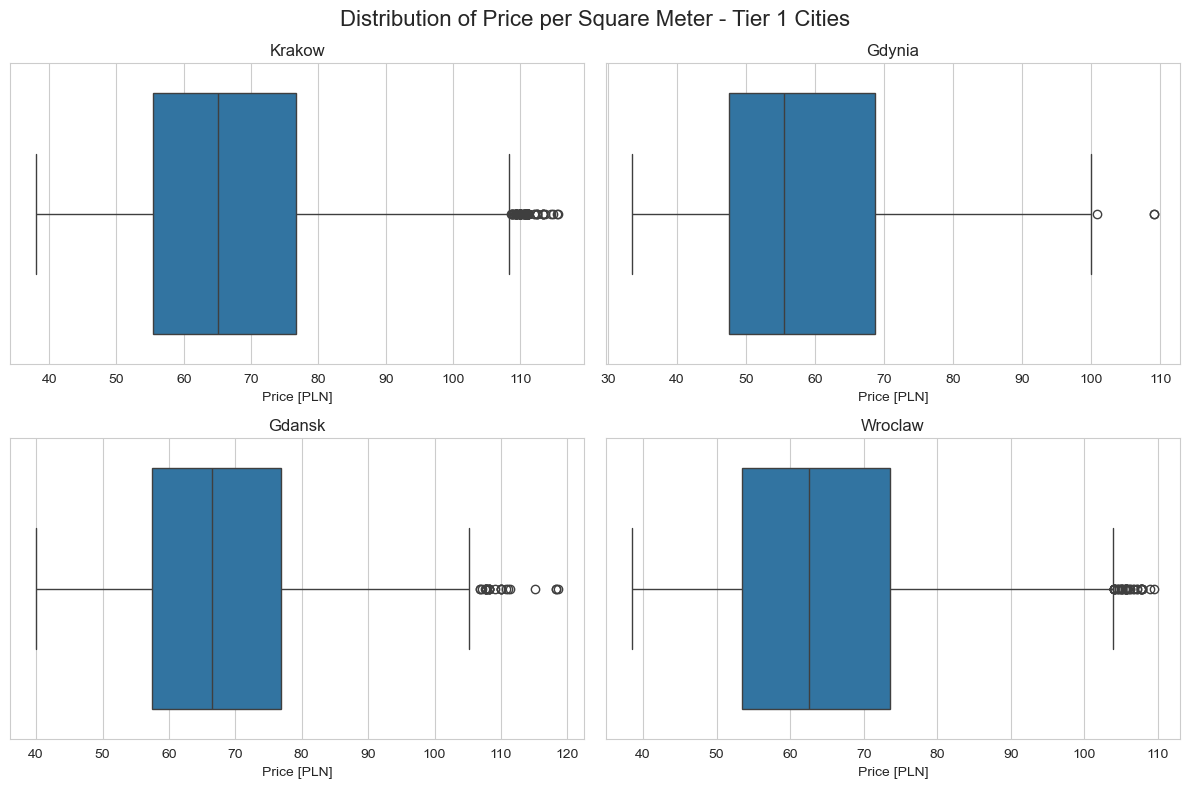

In [36]:
viz_cluster_1.boxplots_test(cluster_1_cities,'price_per_m2',  'Distribution of Price per Square Meter - Tier 1 Cities', 2,2)

#### 4.2.2.2 Cluster 2

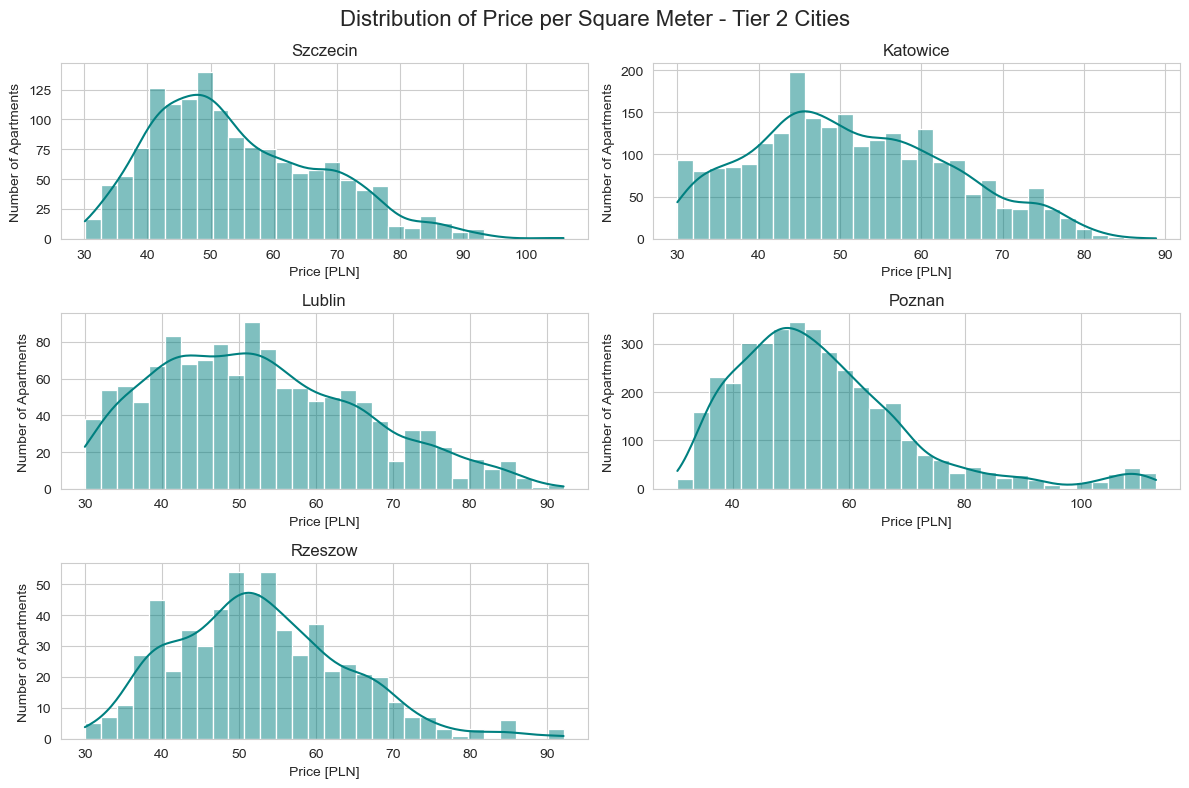

In [37]:
viz_cluster_2.histplots_test(cluster_2_cities,'price_per_m2','Distribution of Price per Square Meter - Tier 2 Cities',3,2)

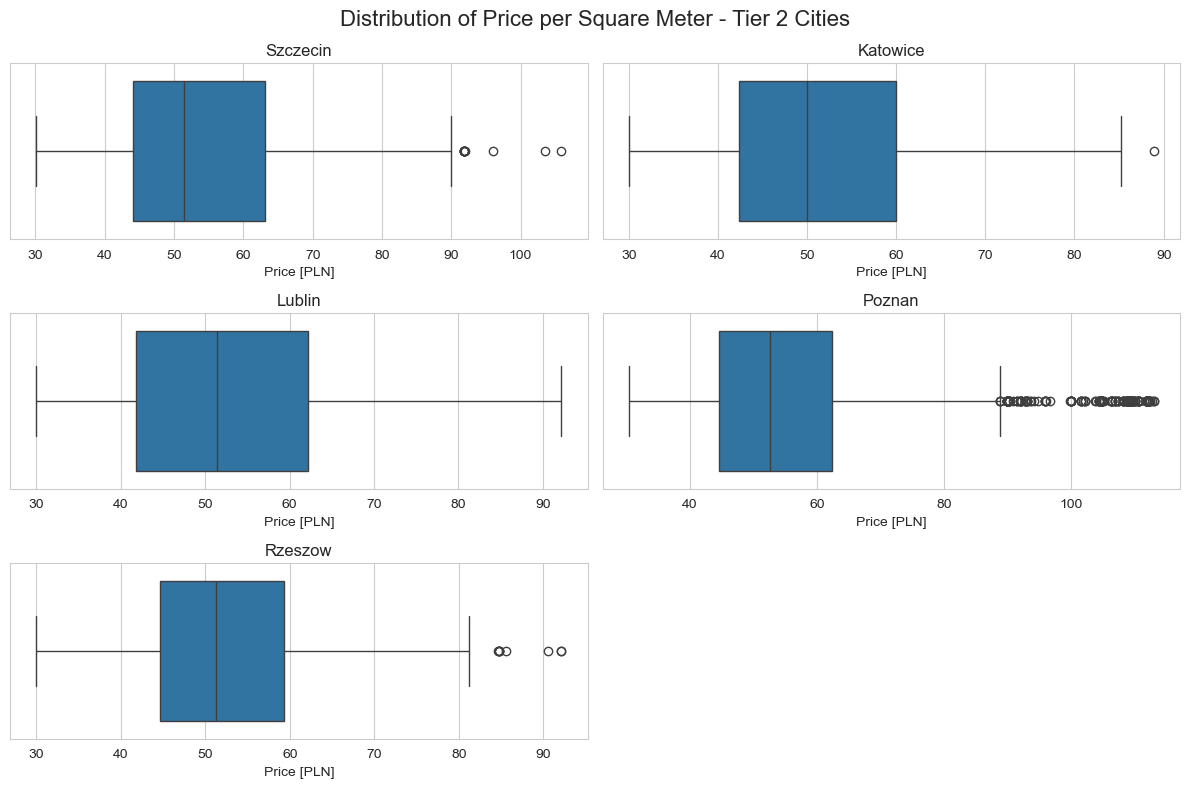

In [38]:
viz_cluster_2.boxplots_test(cluster_2_cities,'price_per_m2',  'Distribution of Price per Square Meter - Tier 2 Cities', 3,2)

#### 4.2.2.3 Cluster 3

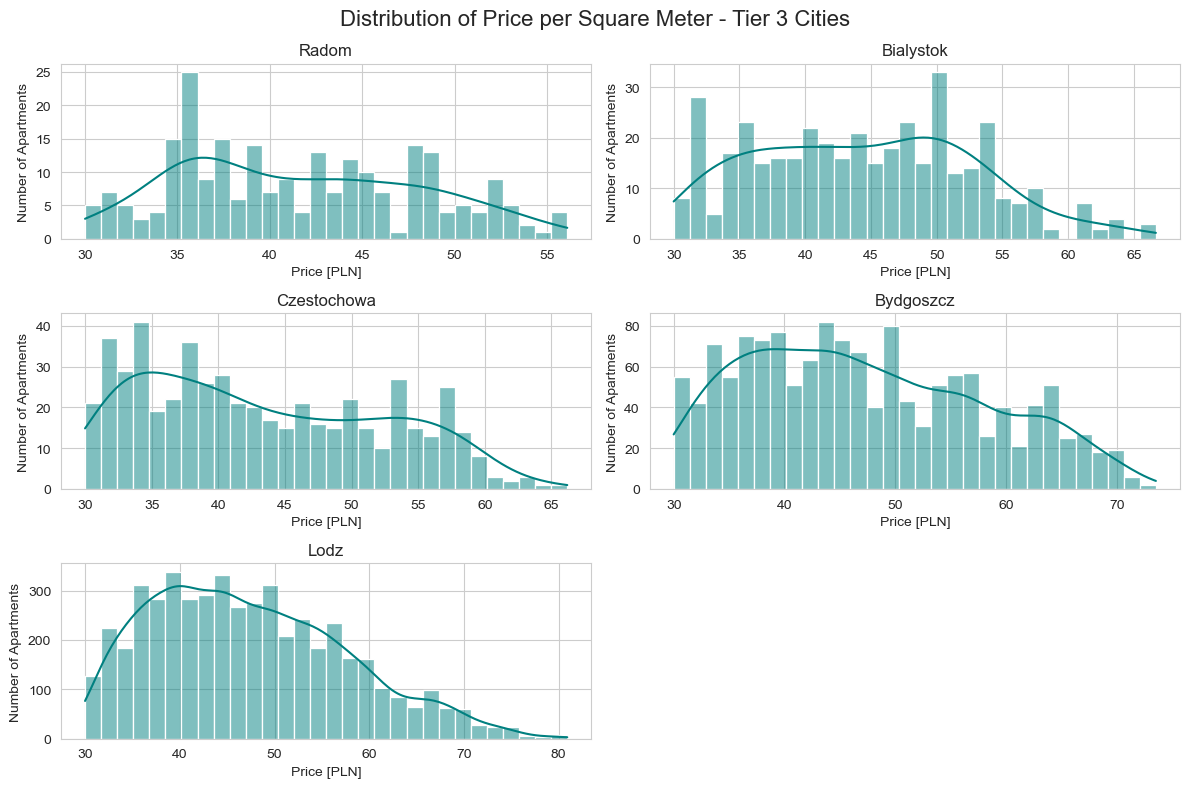

In [39]:
viz_cluster_3.histplots_test(cluster_3_cities,'price_per_m2','Distribution of Price per Square Meter - Tier 3 Cities',3,2)

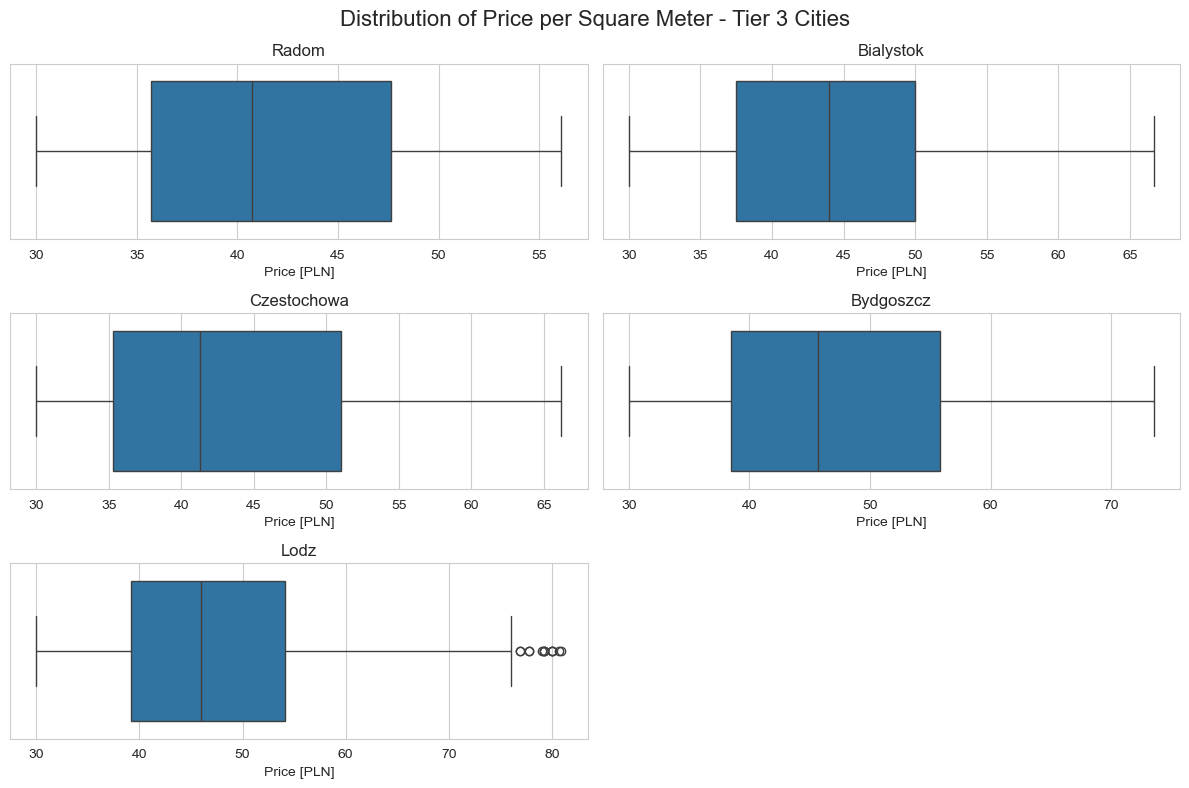

In [40]:
viz_cluster_3.boxplots_test(cluster_3_cities,'price_per_m2',  'Distribution of Price per Square Meter - Tier 3 Cities', 3,2)

Visual inspection of the price per square meter histograms and boxplots reveals that the distributions across the cities are not normal. While they might be less severely right-skewed than the absolute total prices, they still exhibit clear non-normal characteristics, such as multimodality (multiple peaks), varying spreads, and uneven shapes. Given these obvious deviations from normality across all tiers.

**Conclusion**
Since the fundamental assumption of a normal distribution required for parametric testing  is visibly violated, the non-parametric Kruskal-Wallis test remains the most appropriate.

## 4.3 Kruskal Wallis Tests - Price

### 4.3.1 Tier 1

**Hypotheses for Kruskal Wallis Test**
* **H0:** The distribution of prices is the same across all cities in Tier 1.
* **H1:** At least one city has a different price distribution compared to the others.

In [41]:
groups_1 = [df_cluster_1[df_cluster_1['city'] == city]['price'] for city in cluster_1_cities]
stat, pvalue = stats.kruskal(*groups_1)

In [42]:
print(f"Kurskal Wallis Statistic H: {stat}")
print(f"P value: {pvalue}")
print(cluster_1_median_price.to_string())

Kurskal Wallis Statistic H: 47.29318942880552
P value: 3.0106606456286376e-10
city
gdansk     2950.0
gdynia     2800.0
krakow     3000.0
wroclaw    3000.0


### 4.3.2 Posthoc Dunn Test -  Tier 1

In [43]:
dunn_results_1 = sp.posthoc_dunn(df_cluster_1, val_col='price', group_col='city', p_adjust='bonferroni')

In [44]:
print(dunn_results_1.round(4))

         gdansk  gdynia  krakow  wroclaw
gdansk   1.0000     0.0  0.6284      1.0
gdynia   0.0000     1.0  0.0000      0.0
krakow   0.6284     0.0  1.0000      1.0
wroclaw  1.0000     0.0  1.0000      1.0


In [45]:
print(dunn_results_1 < 0.05)

         gdansk  gdynia  krakow  wroclaw
gdansk    False    True   False    False
gdynia     True   False    True     True
krakow    False    True   False    False
wroclaw   False    True   False    False


**Insights:**

The resulting p-value (~0.000) is lower than the common significance level $\alpha = 0.05$. This gives us grounds to reject H0 in favor of the alternative hypothesis. This signifies that at least one city has a different price distribution. The post-hoc Dunn's test revealed that the price distribution for Gdynia differs significantly from the other cities in this tier, with its median price (2800 PLN) being noticeably lower than the rest.

### 4.3.3 Tier 2

**Hypotheses for Kruskal Wallis Test**
* **H0:** The distribution of prices is the same across all cities in Tier 2.
* **H1:** At least one city has a different price distribution compared to the others.

In [46]:
groups_2 = [df_cluster_2[df_cluster_2['city'] == city]['price'] for city in cluster_2_cities]
stat, pvalue = stats.kruskal(*groups_2)

In [47]:
print(f"Kurskal Wallis Statistic H: {stat}")
print(f"P value: {pvalue}")
print(cluster_2_median_price.to_string())

Kurskal Wallis Statistic H: 39.14221729241462
P value: 6.510782809486658e-08
city
katowice    2364.0
lublin      2500.0
poznan      2400.0
rzeszow     2500.0
szczecin    2500.0


### 4.3.4 Posthoc Dunn Test - Tier 2

In [48]:
dunn_results_2 = sp.posthoc_dunn(df_cluster_2, val_col='price', group_col='city', p_adjust='bonferroni')

In [49]:
print(dunn_results_2.round(4))

          katowice  lublin  poznan  rzeszow  szczecin
katowice    1.0000  0.2223  0.2712   0.0016    0.0000
lublin      0.2223  1.0000  1.0000   0.6009    0.0410
poznan      0.2712  1.0000  1.0000   0.0909    0.0002
rzeszow     0.0016  0.6009  0.0909   1.0000    1.0000
szczecin    0.0000  0.0410  0.0002   1.0000    1.0000


In [50]:
print(dunn_results_2 < 0.05)

          katowice  lublin  poznan  rzeszow  szczecin
katowice     False   False   False     True      True
lublin       False   False   False    False      True
poznan       False   False   False    False      True
rzeszow       True   False   False    False     False
szczecin      True    True    True    False     False


**Insights:**

The resulting p-value(~0.000) is lower than the common significance level $\alpha = 0.05$. This gives us grounds to reject H0 in favor of the alternative hypothesis. This signifies that at least one city has a different price distribution. 

The post-hoc Dunn's test revealed three specific relationships:
* The price distribution for Katowice differs significantly from Rzeszów and Szczecin, with its median price(2364 PLN) being noticeably lower.
* Similarly Poznań median price(2400 PLN) has a significantly lower price distribution compare to Szczecin.
* Interesingly the test detect a statistically significant difference between Lublin and Szczecin, despite both cities sharing the exact same median price(2500 PLN). This indicates that while their central values are identical, the underlying shape of spread of their prices differs significantly.
  

### 4.3.5 Tier 3

**Hypotheses for Kruskal Wallis Test**
* **H0:** The distribution of prices is the same across all cities in Tier 3.
* **H1:** At least one city has a different price distribution compared to the others.

In [51]:
groups_3 = [df_cluster_3[df_cluster_3['city'] == city]['price'] for city in cluster_3_cities]
stat, pvalue = stats.kruskal(*groups_3)

In [52]:
print(f"Kurskal Wallis Statistic H: {stat}")
print(f"P value: {pvalue}")
print(cluster_3_median_price.to_string())

Kurskal Wallis Statistic H: 27.23999717761589
P value: 1.7776943824993513e-05
city
bialystok      2000.0
bydgoszcz      1990.0
czestochowa    2000.0
lodz           2000.0
radom          2000.0


### 4.3.6 Posthoc Dunn Test - Tier 3

In [53]:
dunn_results_3 = sp.posthoc_dunn(df_cluster_3, val_col='price', group_col='city', p_adjust='bonferroni')
print(dunn_results_3.round(4))

             bialystok  bydgoszcz  czestochowa    lodz   radom
bialystok       1.0000     0.2622       0.2679  1.0000  1.0000
bydgoszcz       0.2622     1.0000       1.0000  0.0001  0.9179
czestochowa     0.2679     1.0000       1.0000  0.0077  0.7541
lodz            1.0000     0.0001       0.0077  1.0000  1.0000
radom           1.0000     0.9179       0.7541  1.0000  1.0000


In [54]:
print(dunn_results_3 < 0.05)

             bialystok  bydgoszcz  czestochowa   lodz  radom
bialystok        False      False        False  False  False
bydgoszcz        False      False        False   True  False
czestochowa      False      False        False   True  False
lodz             False       True         True  False  False
radom            False      False        False  False  False


**Insights:**

The resulting p-value(~0.000) is lower than the common significance level $\alpha = 0.05$. This gives us grounds to reject H0 in favor of the alternative hypothesis. This signifies that at least one city has a different price distribution.

The post-hoc Dunn's test revealed two particularly interesting cases regarding business vs statistical significance:
* Łódź differs significantly from Częstochowa despite their median prices being identical.
* Łódź differs significantly from Bydgoszcz even though the difference in their median prices is only 10 PL

These findings highlight a crucial property of the Kruskal-Wallis test: the statistical significance detected in these specific pairs is not driven by a meaningful shift in central tendency (medians), but rather by substantial differences in the underlying shape, spread, or variance of their price distributions.


## 4.4 Kruskal Wallis Tests - Price per Square Meter

### 4.4.1  Tier 1

**Hypotheses for Kruskal Wallis Test**
* **H0:** The distribution of prices per square meter is the same across all cities in Tier 1.
* **H1:** At least one city has a different price per square meter distribution compared to the others.

In [55]:
groups_4 = [df_cluster_1[df_cluster_1['city'] == city]['price_per_m2'] for city in cluster_1_cities]
stat, pvalue = stats.kruskal(*groups_4)

In [56]:
print(f"Kurskal Wallis Statistic H: {stat}")
print(f"P value: {pvalue}")
print(cluster_1_median_per_m2.to_string())

Kurskal Wallis Statistic H: 544.570834961115
P value: 1.0440186328985174e-117
city
gdansk     66.54
gdynia     55.56
krakow     65.12
wroclaw    62.50


### 4.4.2 Posthoc Dunn Test -  Tier 1

In [57]:
dunn_results_4 = sp.posthoc_dunn(df_cluster_1, val_col='price_per_m2', group_col='city', p_adjust='bonferroni')
print(dunn_results_4.round(4))

         gdansk  gdynia  krakow  wroclaw
gdansk   1.0000     0.0  0.0005      0.0
gdynia   0.0000     1.0  0.0000      0.0
krakow   0.0005     0.0  1.0000      0.0
wroclaw  0.0000     0.0  0.0000      1.0


In [58]:
print(dunn_results_4 < 0.05)

         gdansk  gdynia  krakow  wroclaw
gdansk    False    True    True     True
gdynia     True   False    True     True
krakow     True    True   False     True
wroclaw    True    True    True    False


**Insights:**

The resulting p-value(~0.000) is lower than the common significance level $\alpha = 0.05$. This gives us grounds to reject H0 in favor of the alternative hypothesis. This signifies that at least one city has a different price per square meter distribution.

The post-hoc Dunn's test revealed a very strict pattern: **every single city in this tier has a statistically distinct price per square meter distribution**. Specifically:
* Gdynia stands out with a significantly lower median price per square meter (55.56 PLN/m²) compared to all other cities in this tier.
* Gdańsk (66.54 PLN/m²), Kraków (65.12 PLN/m²), and Wrocław (62.50 PLN/m²) also differ significantly from one another. Even though their median values are relatively close to each other, the test confirms that their overall market structures—meaning the underlying shape, spread, or variance of their prices per square meter—are statistically unique.


### 4.4.3  Tier 2

**Hypotheses for Kruskal Wallis Test**
* **H0:** The distribution of prices per square meter is the same across all cities in Tier 2.
* **H1:** At least one city has a different price per square meter distribution compared to the others.

In [59]:
groups_5 = [df_cluster_2[df_cluster_2['city'] == city]['price_per_m2'] for city in cluster_2_cities]
stat, pvalue = stats.kruskal(*groups_5)

In [60]:
print(f"Kurskal Wallis Statistic H: {stat}")
print(f"P value: {pvalue}")
print(cluster_2_median_per_m2.to_string())

Kurskal Wallis Statistic H: 71.40043037710038
P value: 1.14884688640984e-14
city
katowice    50.00
lublin      51.39
poznan      52.58
rzeszow     51.32
szczecin    51.43


### 4.4.4 Posthoc Dunn Test -  Tier 2

In [61]:
dunn_results_5 = sp.posthoc_dunn(df_cluster_2, val_col='price_per_m2', group_col='city', p_adjust='bonferroni')
print(dunn_results_5.round(4))

          katowice  lublin  poznan  rzeszow  szczecin
katowice    1.0000  0.7179  0.0000   0.1644    0.0000
lublin      0.7179  1.0000  0.0001   1.0000    0.0223
poznan      0.0000  0.0001  1.0000   0.2852    1.0000
rzeszow     0.1644  1.0000  0.2852   1.0000    1.0000
szczecin    0.0000  0.0223  1.0000   1.0000    1.0000


In [62]:
print(dunn_results_5 < 0.05)

          katowice  lublin  poznan  rzeszow  szczecin
katowice     False   False    True    False      True
lublin       False   False    True    False      True
poznan        True    True   False    False     False
rzeszow      False   False   False    False     False
szczecin      True    True   False    False     False


**Insights:**

The resulting p-value(~0.000) is lower than the common significance level $\alpha = 0.05$. This gives us grounds to reject H0 in favor of the alternative hypothesis. This signifies that at least one city has a different price per square meter distribution.

### 4.4.5  Tier 3

**Hypotheses for Kruskal Wallis Test**
* **H0:** The distribution of prices per square meter is the same across all cities in Tier 3.
* **H1:** At least one city has a different price per square meter distribution compared to the others.

In [63]:
groups_6 = [df_cluster_3[df_cluster_3['city'] == city]['price_per_m2'] for city in cluster_3_cities]
stat, pvalue = stats.kruskal(*groups_6)

In [64]:
print(f"Kurskal Wallis Statistic H: {stat}")
print(f"P value: {pvalue}")
print(cluster_3_median_per_m2.to_string())

Kurskal Wallis Statistic H: 148.3784987961604
P value: 4.530791939690907e-31
city
bialystok      44.00
bydgoszcz      45.70
czestochowa    41.30
lodz           46.00
radom          40.74


### 4.4.6 Posthoc Dunn Test -  Tier 3

In [65]:
dunn_results_6 = sp.posthoc_dunn(df_cluster_3, val_col='price_per_m2', group_col='city', p_adjust='bonferroni')
print(dunn_results_6.round(4))

             bialystok  bydgoszcz  czestochowa  lodz   radom
bialystok       1.0000     0.0003       0.3085   0.0  0.0014
bydgoszcz       0.0003     1.0000       0.0000   1.0  0.0000
czestochowa     0.3085     0.0000       1.0000   0.0  0.2902
lodz            0.0000     1.0000       0.0000   1.0  0.0000
radom           0.0014     0.0000       0.2902   0.0  1.0000


In [66]:
print(dunn_results_6 < 0.05)

             bialystok  bydgoszcz  czestochowa   lodz  radom
bialystok        False       True        False   True   True
bydgoszcz         True      False         True  False   True
czestochowa      False       True        False   True  False
lodz              True      False         True  False   True
radom             True       True        False   True  False


**Insights:**

The resulting p-value(~0.000) is lower than the common significance level $\alpha = 0.05$. This gives us grounds to reject H0 in favor of the alternative hypothesis. This signifies that at least one city has a different price per square meter distribution.

## 4.5 Inter-Cluster Comparison - Kurskal Wallis Test

### 4.5.1 Data Preparation

In [67]:
cluster_1_median_price = df_cluster_1['price'].median()
cluster_2_median_price = df_cluster_2['price'].median()
cluster_3_median_price = df_cluster_3['price'].median()

In [68]:
cluster_1_median_m2 = df_cluster_1['price_per_m2'].median()
cluster_2_median_m2 = df_cluster_2['price_per_m2'].median()
cluster_3_median_m2 = df_cluster_3['price_per_m2'].median()

In [69]:
df_c1 = df_cluster_1.copy()
df_c2 = df_cluster_2.copy()
df_c3 = df_cluster_3.copy()

In [70]:
df_c1['cluster_tier'] = 'Tier 1'
df_c2['cluster_tier'] = 'Tier 2'
df_c3['cluster_tier'] = 'Tier 3'
df_all_clusters = pd.concat([df_c1,df_c2,df_c3])

### 4.5.1 Price

**Hypotheses for Kruskal Wallis Test**
* **H0:** The distribution of price is the same across all Tiers.
* **H1:** At least one tier has a different price distribution compared to the others

In [71]:
stat, pvalue = stats.kruskal(
    df_cluster_1['price'],
    df_cluster_2['price'],
    df_cluster_3['price']
)


In [72]:
print(f"Kurskal Wallis Statistic H: {stat}")
print(f"P value: {pvalue}")
print(f"Median for cluster 1: {cluster_1_median_price}\nMedian for cluster 2: {cluster_2_median_price}\nMedian for cluster 3: {cluster_3_median_price}")

Kurskal Wallis Statistic H: 10141.92132480196
P value: 0.0
Median for cluster 1: 2999.0
Median for cluster 2: 2400.0
Median for cluster 3: 2000.0


#### 4.5.1.1 Posthoc Dunn Test

In [73]:
dunn_cluster_price_results = sp.posthoc_dunn(df_all_clusters, val_col='price', group_col='cluster_tier', p_adjust='bonferroni')
print(dunn_cluster_price_results.round(6))

        Tier 1  Tier 2  Tier 3
Tier 1     1.0     0.0     0.0
Tier 2     0.0     1.0     0.0
Tier 3     0.0     0.0     1.0


In [74]:
print(dunn_cluster_price_results < 0.05)

        Tier 1  Tier 2  Tier 3
Tier 1   False    True    True
Tier 2    True   False    True
Tier 3    True    True   False


**Insights:**

The resulting p-value(~0.000) is lower than the common significance level $\alpha = 0.05$. This gives us grounds to reject H0 in favor of the alternative hypothesis. This signifies that at least one tier has a different price  distribution.

### 4.5.2 Price per Square Meter

**Hypotheses for Kruskal Wallis Test**
* **H0:** The distribution of price per square meter is the same across all Tiers.
* **H1:** At least one tier has a different price per square meter distribution compared to the others

In [75]:
stat, pvalue = stats.kruskal(
    df_cluster_1['price_per_m2'],
    df_cluster_2['price_per_m2'],
    df_cluster_3['price_per_m2']
)


In [76]:
print(f"Kurskal Wallis Statistic H: {stat}")
print(f"P value: {pvalue}")
print(f"Median for cluster 1: {cluster_1_median_m2}\nMedian for cluster 2: {cluster_2_median_m2}\nMedian for cluster 3: {cluster_3_median_m2}")

Kurskal Wallis Statistic H: 10874.008792826344
P value: 0.0
Median for cluster 1: 64.07
Median for cluster 2: 51.595
Median for cluster 3: 45.42


#### 4.5.2.1 Posthoc Dunn Test

In [77]:
dunn_cluster_m2_results = sp.posthoc_dunn(df_all_clusters, val_col='price_per_m2', group_col='cluster_tier', p_adjust='bonferroni')
print(dunn_cluster_m2_results.round(6))

        Tier 1  Tier 2  Tier 3
Tier 1     1.0     0.0     0.0
Tier 2     0.0     1.0     0.0
Tier 3     0.0     0.0     1.0


In [78]:
print(dunn_cluster_m2_results < 0.05)

        Tier 1  Tier 2  Tier 3
Tier 1   False    True    True
Tier 2    True   False    True
Tier 3    True    True   False


**Insights:**

The resulting p-value(~0.000) is lower than the common significance level $\alpha = 0.05$. This gives us grounds to reject H0 in favor of the alternative hypothesis. This signifies that at least one tier has a different price per square meter distribution.

# 5. Multiple linear regression

## 5.1 Select variables 

In [79]:
df.columns

Index(['id', 'date', 'city', 'type', 'squareMeters', 'rooms', 'floor',
       'floorCount', 'buildYear', 'latitude', 'longitude', 'centreDistance',
       'poiCount', 'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'hasParkingSpace', 'hasBalcony',
       'hasElevator', 'hasSecurity', 'hasStorageRoom', 'price',
       'price_per_m2'],
      dtype='object')

In [80]:
df_numeric = df.select_dtypes(include='number')
correl = df_numeric.corr()['price']
correl.sort_values(ascending=False)

price                   1.000000
squareMeters            0.775136
rooms                   0.652898
price_per_m2            0.627511
longitude               0.312440
poiCount                0.178440
hasElevator             0.157790
latitude                0.102704
floor                   0.094347
floorCount              0.076009
hasSecurity             0.056378
hasParkingSpace         0.046517
hasBalcony              0.041030
buildYear               0.035583
centreDistance         -0.002688
postOfficeDistance     -0.055865
kindergartenDistance   -0.064107
pharmacyDistance       -0.068305
schoolDistance         -0.071169
hasStorageRoom         -0.081766
collegeDistance        -0.085190
clinicDistance         -0.146919
restaurantDistance     -0.152098
Name: price, dtype: float64

In [81]:
df_regression = df[['city','type','squareMeters','centreDistance','price']]

## 5.2 Preprocessing

In [82]:
df_regression = pd.get_dummies(df_regression, drop_first=True, dtype=int)

### 5.3 Create model

In [83]:
y = df_regression['price']
X = df_regression.drop(columns=['price'])
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                 1.095e+04
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:38:06   Log-Likelihood:            -5.9719e+05
No. Observations:               70054   AIC:                         1.194e+06
Df Residuals:                   70035   BIC:                         1.195e+06
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -587.0756     62.19

Białystok i apartament

## 5.4 VIF

In [84]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [91]:
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
    for i in range(len(X.columns))
]

In [92]:
print("\nVIF:\n", vif_data)


VIF:
              Variable         VIF
0               const  182.335011
1        squareMeters    1.099090
2      centreDistance    1.241663
3      city_bydgoszcz    4.434690
4    city_czestochowa    2.330325
5         city_gdansk    9.499963
6         city_gdynia    4.596683
7       city_katowice    6.707316
8         city_krakow   26.715470
9           city_lodz   12.469683
10        city_lublin    4.143845
11        city_poznan   10.074333
12         city_radom    1.588060
13       city_rzeszow    2.487014
14      city_szczecin    4.573914
15      city_warszawa   43.275867
16       city_wroclaw   15.976303
17  type_blockOfFlats    1.176444
18      type_tenement    1.176795


In [87]:
residuals = model.resid
predicted = model.fittedvalues

In [88]:
viz_reg = DataVisualizer(df_regression)

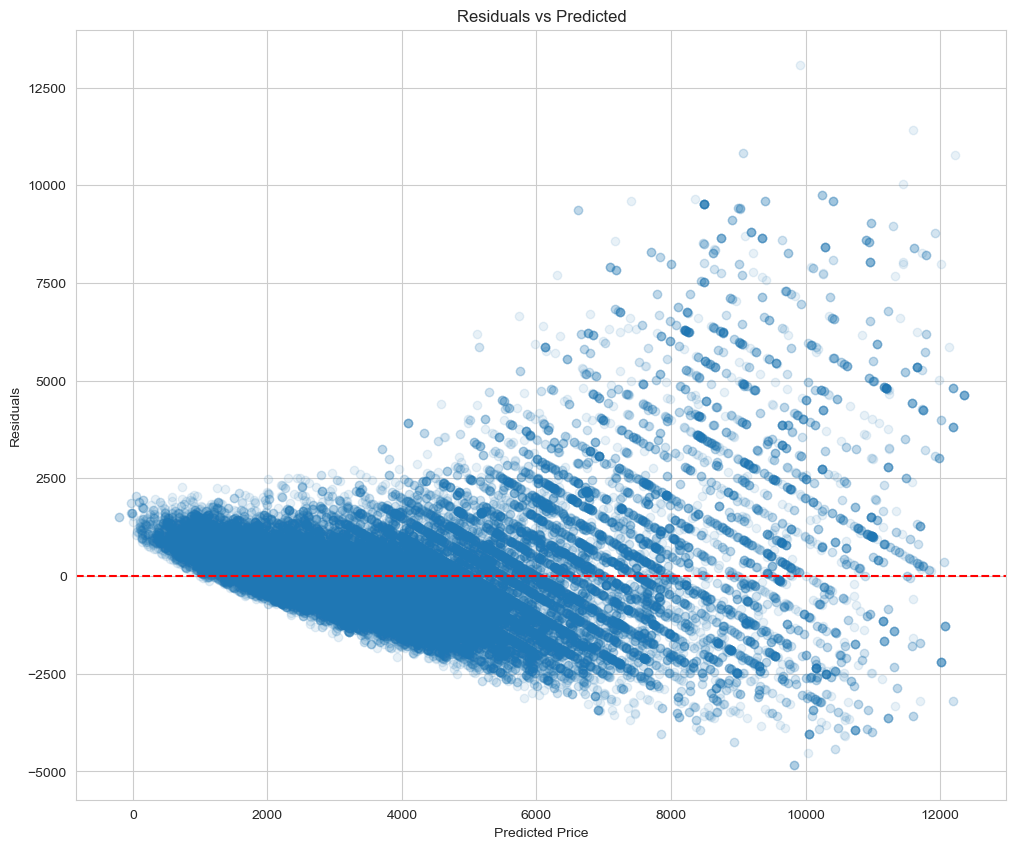

In [89]:
viz_reg.scatterplot_test(predicted, residuals)

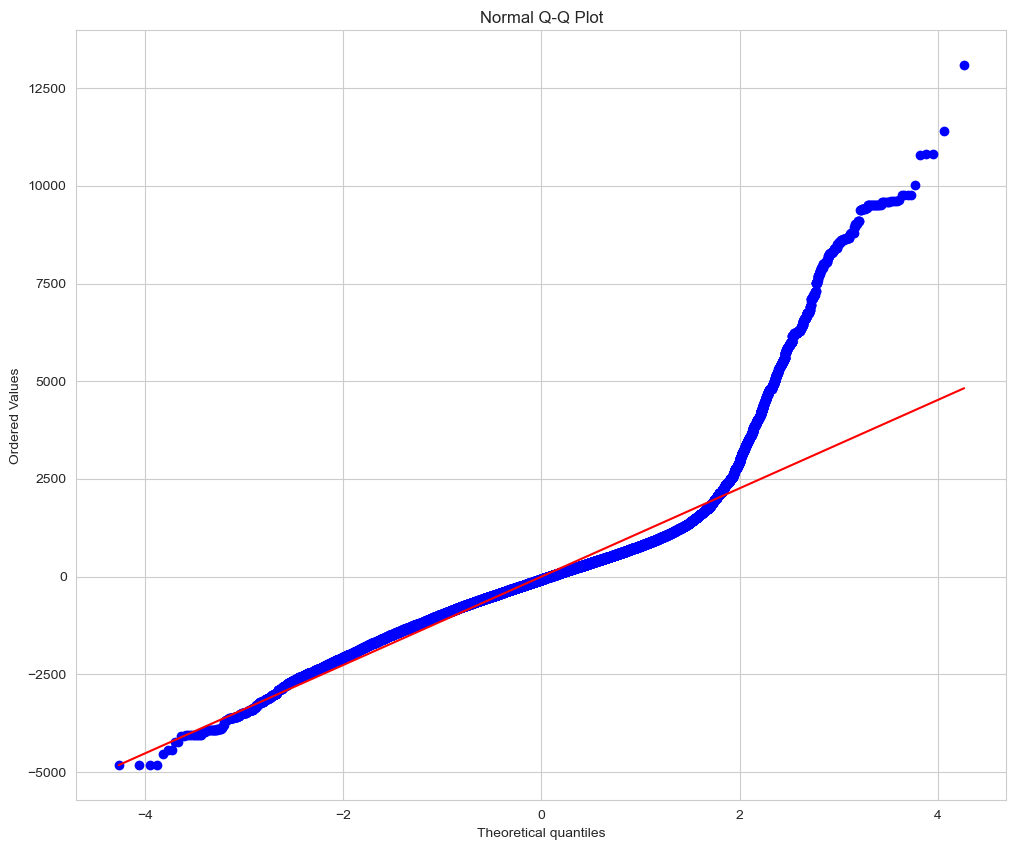

In [90]:
viz_reg.probplot(residuals)